# 11 — Candidate Bus-Route Segments: Scoring Pipeline

Incremental, step-by-step notebook. Each cell is a deliberate step; decisions are made as results come in.

In [1]:
import sys
from pathlib import Path

project_root = Path("..").resolve()
sys.path.insert(0, str(project_root))

import geopandas as gpd

from src.utils.config import (
    INTEGRATED_BUILDINGS,
    ENTRANCES_DEMOGRAPHICS_LAYER,
    PEDESTRIAN_NETWORK_GPKG,
)

print("Dependencies loaded")

Dependencies loaded


In [2]:
# Load address points with demographics
gdf_entrances = gpd.read_file(INTEGRATED_BUILDINGS, layer=ENTRANCES_DEMOGRAPHICS_LAYER)
print(f"Entrances: {len(gdf_entrances):,} | CRS: {gdf_entrances.crs}")
print(gdf_entrances.columns.tolist())

Entrances: 11,367 | CRS: EPSG:25832
['entrance_id', 'positioning_type', 'status', 'building_id', 'use_code', 'use_description', 'use_category', 'construction_year', 'construction_era', 'floors', 'total_area_m2', 'residential_area_m2', 'commercial_area_m2', 'wall_material', 'roof_material', 'heating_type', 'gm_id', 'neighbourhood_name', 'has_building', 'entrance_source', 'n_dwelling_units', 'avg_unit_m2', 'dwelling_typology', 'dominant_group', 'pop_children_0_14_low', 'pop_young_adults_15_29_low', 'pop_working_age_30_64_low', 'pop_older_adults_65_79_low', 'pop_very_elderly_80plus_low', 'pop_children_0_14_mid', 'pop_young_adults_15_29_mid', 'pop_working_age_30_64_mid', 'pop_older_adults_65_79_mid', 'pop_very_elderly_80plus_mid', 'pop_children_0_14_high', 'pop_young_adults_15_29_high', 'pop_working_age_30_64_high', 'pop_older_adults_65_79_high', 'pop_very_elderly_80plus_high', 'pop_total_low', 'pop_total_mid', 'pop_total_high', 'geometry']


In [3]:
# Load pedestrian network
gdf_edges = gpd.read_file(PEDESTRIAN_NETWORK_GPKG, layer="edges")
print(f"Edges: {len(gdf_edges):,} | CRS: {gdf_edges.crs}")
print(gdf_edges.columns.tolist())

Edges: 15,058 | CRS: EPSG:25832
['u', 'v', 'key', 'osmid', 'highway', 'lanes', 'maxspeed', 'name', 'oneway', 'reversed', 'length', 'travel_time', 'from', 'to', 'service', 'width', 'access', 'tunnel', 'ref', 'bridge', 'junction', 'geometry']


In [4]:
# Aggregate age bands into the three groups that match the benefit curves.
# Reduced mobility is cross-cutting (not an age group in the data) — deferred.
#
#   working_age  15–64  =  young_adults_15_29  +  working_age_30_64
#   elderly      65+    =  older_adults_65_79  +  very_elderly_80plus
#   children     0–14   =  children_0_14

GROUPS = {
    "working_age": ["pop_young_adults_15_29", "pop_working_age_30_64"],
    "elderly": ["pop_older_adults_65_79", "pop_very_elderly_80plus"],
    "children": ["pop_children_0_14"],
}

for group, source_prefixes in GROUPS.items():
    for scenario in ("low", "mid", "high"):
        cols = [f"{p}_{scenario}" for p in source_prefixes]
        gdf_entrances[f"pop_{group}_{scenario}"] = gdf_entrances[cols].sum(axis=1)

# Verify totals against existing pop_total_mid
implied_total = (
    gdf_entrances["pop_working_age_mid"]
    + gdf_entrances["pop_elderly_mid"]
    + gdf_entrances["pop_children_mid"]
)
total_pop = gdf_entrances["pop_total_mid"].sum()
implied_sum = implied_total.sum()
print(f"pop_total_mid sum : {total_pop:,.0f}")
print(f"implied total sum : {implied_sum:,.0f}  (should match — covers all age groups)")
print()
print("New columns added:")
for group in GROUPS:
    cols_added = [f"pop_{group}_{s}" for s in ("low", "mid", "high")]
    totals = {
        s: gdf_entrances[f"pop_{group}_{s}"].sum() for s in ("low", "mid", "high")
    }
    print(
        f"  {group:>15}  low={totals['low']:>8,.0f}  mid={totals['mid']:>8,.0f}  high={totals['high']:>8,.0f}"
    )

pop_total_mid sum : 356,021
implied total sum : 356,021  (should match — covers all age groups)

New columns added:
      working_age  low= 274,607  mid= 274,635  high= 275,284
          elderly  low=  29,756  mid=  29,940  high=  30,120
         children  low=  48,910  mid=  51,446  high=  56,840


In [5]:
gdf_entrances.head()

,entrance_id,positioning_type,status,building_id,use_code,use_description,use_category,construction_year,construction_era,floors,...,geometry,pop_working_age_low,pop_working_age_mid,pop_working_age_high,pop_elderly_low,pop_elderly_mid,pop_elderly_high,pop_children_low,pop_children_mid,pop_children_high
0,0d7cb9f7-6889-42bf-86a8-88bb12b2d1b1,TD,8,206b216c-95f5-46cb-a740-edfe58fd8bde,140.0,Apartment building,Residential,1906.0,1900-1930,5.0,...,POINT (723677.42 6177181.24),12.520543,12.604117,12.971093,1.843212,1.896702,1.949446,2.991738,4.145232,6.903612
1,0a3f507a-ee8d-32b8-e044-0003ba298018,TD,8,ecbf04b9-8e42-474b-9af3-5540495f52fe,140.0,Apartment building,Residential,1880.0,1850-1900,5.0,...,POINT (723840.51 6177412.51),5.681693,5.708876,5.727958,0.774047,0.786362,0.798365,0.803201,0.650734,0.286135
2,0a3f507a-41ed-32b8-e044-0003ba298018,TD,8,a3c52b68-a727-4f19-9ab1-c38c60ab2645,140.0,Apartment building,Residential,1981.0,1980-2000,4.0,...,POINT (723376.4 6177190.17),23.396313,23.223487,23.157155,3.282143,3.340282,3.395863,5.265613,5.935159,6.835932
3,93d9efdb-13a8-4221-9718-75d2790ea99c,TD,8,5d7d2a1b-467e-4f59-b1a2-0afaca505bcf,321.0,Office,Office/Retail,1890.0,1850-1900,2.0,...,POINT (722545.44 6178351.65),4.708684,4.721636,4.716987,0.343713,0.343536,0.343356,0.592657,0.484999,0.218529
4,5441e893-8d4c-4896-865d-6081dd2b9c2a,TD,8,e3cd51de-ea0c-42e7-88f2-35aaf416ff82,223.0,Workshop,Production/Agriculture,1900.0,1900-1930,2.0,...,POINT (723053.96 6178087.344),0.824763,0.790503,0.775950,0.061953,0.057707,0.053687,0.271783,0.460841,0.928782


In [6]:
from cityseer.tools import io, graphs

# Build primal graph from the processed GeoPackage (stays in EPSG:25832)
G = io.nx_from_generic_geopandas(gdf_edges)
print(f"Raw graph       : {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")

# Remove intermediate (filler) nodes
G = graphs.nx_remove_filler_nodes(G)
print(f"After filler rm : {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")

# Decompose all edges to ≤20m segments
G = graphs.nx_decompose(G, decompose_max=20)
print(f"After decompose : {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")

# Convert to dual: each 20m primal edge becomes a dual node positioned at its midpoint.
# The primal edge LineString geometry is stored as the 'primal_edge' attribute on each dual node.
# This is the correct representation for segment-level accessibility scoring.
G_dual = graphs.nx_to_dual(G)
print(
    f"After dual      : {G_dual.number_of_nodes():,} nodes (= primal segments), {G_dual.number_of_edges():,} edges"
)
print("Note: network_structure will be built after live-node marking (next cell)")


  0%|          | 0/15058 [00:00<?, ?it/s]


 12%|█▏        | 1771/15058 [00:00<00:00, 17705.92it/s]


 25%|██▍       | 3700/15058 [00:00<00:00, 18637.34it/s]


 38%|███▊      | 5670/15058 [00:00<00:00, 19118.18it/s]


 50%|█████     | 7582/15058 [00:00<00:00, 19108.33it/s]

...


 95%|█████████▌| 32355/34054 [00:07<00:00, 7541.52it/s]


 97%|█████████▋| 33160/34054 [00:07<00:00, 7691.40it/s]


100%|█████████▉| 33963/34054 [00:07<00:00, 7792.01it/s]


100%|██████████| 34054/34054 [00:07<00:00, 4640.11it/s]

After dual      : 34,054 nodes (= primal segments), 51,766 edges
Note: network_structure will be built after live-node marking (next cell)


In [7]:
from src.utils.config import TRANSPORT_STOPS_OUTPUT

# Load bus routes and build a 15m buffer — candidate segments must intersect this
routes = gpd.read_file(TRANSPORT_STOPS_OUTPUT, layer="routes")
bus_routes = routes[routes["transport_mode"] == "bus"].copy()
bus_buffer = bus_routes.geometry.union_all().buffer(15)
print(f"Bus routes loaded: {len(bus_routes):,} | Buffer CRS: {bus_routes.crs}")

# Mark live=False on all dual nodes whose primal_edge does not intersect the bus corridor.
# CitySeer's Rust backend skips live=False nodes during computation — they still participate
# in routing (so distances are correct) but do not receive score columns.
live_count = 0
dead_count = 0
for node_key, node_data in G_dual.nodes(data=True):
    primal_geom = node_data.get("primal_edge")
    if primal_geom is not None and primal_geom.intersects(bus_buffer):
        live_count += 1
    else:
        node_data["live"] = False
        dead_count += 1

print(f"\nLive  (bus-route segments) : {live_count:,}")
print(f"Dead  (off-route segments) : {dead_count:,}")
print(
    f"Fraction on bus routes     : {live_count / (live_count + dead_count) * 100:.1f}%"
)

# Now build network_structure — live flags are read here and stored in the Rust backend
nodes_gdf, _, network_structure = io.network_structure_from_nx(G_dual)
print(
    f"\nNodes GDF: {len(nodes_gdf):,} rows | geometry type: {nodes_gdf.geometry.geom_type.value_counts().to_dict()}"
)

Bus routes loaded: 148 | Buffer CRS: EPSG:25832


INFO:cityseer.tools.io:Preparing node and edge arrays from networkX graph.



Live  (bus-route segments) : 8,328
Dead  (off-route segments) : 25,726
Fraction on bus routes     : 24.5%



  0%|          | 0/34054 [00:00<?, ?it/s]


 99%|█████████▉| 33851/34054 [00:00<00:00, 338497.41it/s]

...


 90%|████████▉ | 30633/34054 [00:02<00:00, 19829.90it/s]


 97%|█████████▋| 33088/34054 [00:02<00:00, 21154.55it/s]


100%|██████████| 34054/34054 [00:02<00:00, 15548.32it/s]

INFO:cityseer.graph:Edge R-tree built successfully with 51766 items.



Nodes GDF: 34,054 rows | geometry type: {'LineString': 34054}


In [8]:
from cityseer.metrics import layers

# Deduplication key: use building_id where available, fall back to entrance_id.
# Purpose: each building's population is counted once (nearest entrance to each node).
# Entrances with no matched building (null building_id) are treated as independent points.
# Baseline weight: each entrance counts equally (no population weighting)
gdf_entrances["weight_baseline"] = 1.0

gdf_entrances["_data_id"] = gdf_entrances["building_id"].fillna(
    gdf_entrances["entrance_id"]
)
print(
    f"_data_id unique values : {gdf_entrances['_data_id'].nunique():,}  (of {len(gdf_entrances):,} entrances)"
)

# --- First-pass: mid columns only, single distance threshold ---
# Uncomment the full lists below once this run validates correctly.

DISTANCES = list(range(100, 1201, 20))

POP_COLS = [
    "weight_baseline",
    "pop_working_age_low",
    "pop_working_age_mid",
    "pop_working_age_high",
    "pop_elderly_low",
    "pop_elderly_mid",
    "pop_elderly_high",
    "pop_children_low",
    "pop_children_mid",
    "pop_children_high",
]
print(f"Distance thresholds : {DISTANCES}")
print(f"Population columns  : {POP_COLS}")

nodes_gdf, _ = layers.compute_stats(
    data_gdf=gdf_entrances,
    stats_column_labels=POP_COLS,
    nodes_gdf=nodes_gdf,
    network_structure=network_structure,
    distances=DISTANCES,
    data_id_col="_data_id",
)

# Column naming: cc_{col}_{stat}_{distance}_nw (unweighted) or _wt (distance-weighted)
# We use _nw (unweighted sums) for the B(d) scoring — the benefit curve handles the weighting.
nw_sum_cols = [c for c in nodes_gdf.columns if "_sum_" in c and c.endswith("_nw")]
print(f"\nNodes GDF shape    : {nodes_gdf.shape}")
print(f"Unweighted sums    : {len(nw_sum_cols)}  → {nw_sum_cols}")

# Sanity check on live nodes only
live_nodes = nodes_gdf[nodes_gdf["live"] == True]
col = "cc_pop_working_age_mid_sum_1200_nw"
if col in nodes_gdf.columns:
    print(f"\nLive nodes: {len(live_nodes):,}")
    print(f"Max {col}: {live_nodes[col].max():,.0f}")
    print(
        f"District total pop_working_age_mid: {gdf_entrances['pop_working_age_mid'].sum():,.0f}"
    )

INFO:cityseer.metrics.layers:Computing statistics.


INFO:cityseer.metrics.layers:Assigning data to network.


INFO:cityseer.data:Assigning 11367 data entries to network nodes (max_dist: 100).


INFO:cityseer.data:Finished assigning data. 22285 assignments added to 4290 nodes.


_data_id unique values : 2,336  (of 11,367 entrances)
Distance thresholds : [100, 120, 140, 160, 180, 200, 220, 240, 260, 280, 300, 320, 340, 360, 380, 400, 420, 440, 460, 480, 500, 520, 540, 560, 580, 600, 620, 640, 660, 680, 700, 720, 740, 760, 780, 800, 820, 840, 860, 880, 900, 920, 940, 960, 980, 1000, 1020, 1040, 1060, 1080, 1100, 1120, 1140, 1160, 1180, 1200]
Population columns  : ['weight_baseline', 'pop_working_age_low', 'pop_working_age_mid', 'pop_working_age_high', 'pop_elderly_low', 'pop_elderly_mid', 'pop_elderly_high', 'pop_children_low', 'pop_children_mid', 'pop_children_high']


...

INFO:cityseer.config:Distance: 1160m, Beta: 0.00345, Walking Time: 14.5 minutes.


INFO:cityseer.config:Distance: 1180m, Beta: 0.00339, Walking Time: 14.75 minutes.


INFO:cityseer.config:Distance: 1200m, Beta: 0.00333, Walking Time: 15.0 minutes.



Nodes GDF shape    : (34054, 7851)
Unweighted sums    : 560  → ['cc_weight_baseline_sum_100_nw', 'cc_weight_baseline_sum_120_nw', 'cc_weight_baseline_sum_140_nw', 'cc_weight_baseline_sum_160_nw', 'cc_weight_baseline_sum_180_nw', 'cc_weight_baseline_sum_200_nw', 'cc_weight_baseline_sum_220_nw', 'cc_weight_baseline_sum_240_nw', 'cc_weight_baseline_sum_260_nw', 'cc_weight_baseline_sum_280_nw', 'cc_weight_baseline_sum_300_nw', 'cc_weight_baseline_sum_320_nw', 'cc_weight_baseline_sum_340_nw', 'cc_weight_baseline_sum_360_nw', 'cc_weight_baseline_sum_380_nw', 'cc_weight_baseline_sum_400_nw', 'cc_weight_baseline_sum_420_nw', 'cc_weight_baseline_sum_440_nw', 'cc_weight_baseline_sum_460_nw', 'cc_weight_baseline_sum_480_nw', 'cc_weight_baseline_sum_500_nw', 'cc_weight_baseline_sum_520_nw', 'cc_weight_baseline_sum_540_nw', 'cc_weight_baseline_sum_560_nw', 'cc_weight_baseline_sum_580_nw', 'cc_weight_baseline_sum_600_nw', 'cc_weight_baseline_sum_620_nw', 'cc_weight_baseline_sum_640_nw', 'cc_weight_


Live nodes: 8,328
Max cc_pop_working_age_mid_sum_1200_nw: 19,970
District total pop_working_age_mid: 274,635


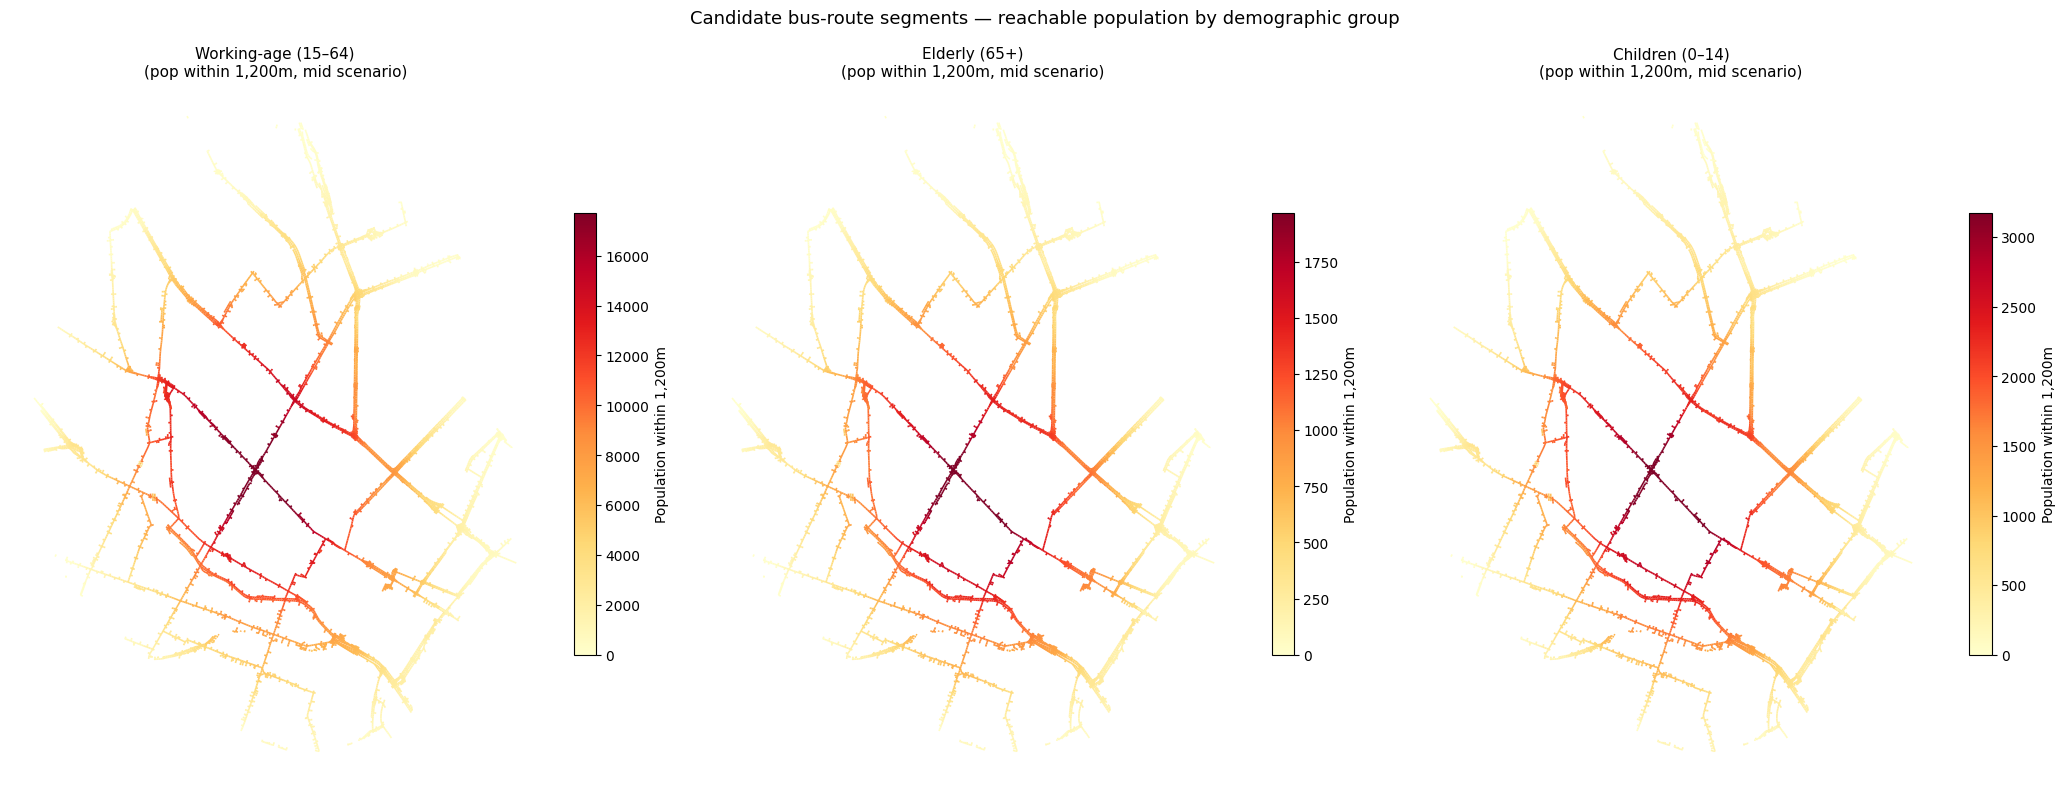


Live segments plotted: 8,328
      working_age  max=  19,970  median=   4,628
          elderly  max=   2,218  median=     500
         children  max=   3,596  median=     814


In [9]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Quick choropleth — live segments only, 1200m cumulative population
live = nodes_gdf[nodes_gdf["live"] == True].copy()

PLOT_COLS = {
    "working_age": "cc_pop_working_age_mid_sum_1200_nw",
    "elderly": "cc_pop_elderly_mid_sum_1200_nw",
    "children": "cc_pop_children_mid_sum_1200_nw",
}
TITLES = {
    "working_age": "Working-age (15–64)",
    "elderly": "Elderly (65+)",
    "children": "Children (0–14)",
}

fig, axes = plt.subplots(1, 3, figsize=(21, 8))

for ax, (group, col) in zip(axes, PLOT_COLS.items()):
    if col not in live.columns:
        ax.set_title(f"{TITLES[group]}\n(column missing — rerun compute_stats)")
        ax.set_axis_off()
        continue

    vmax = live[col].quantile(0.98)  # clip top 2% to avoid outlier stretching
    live.plot(
        column=col,
        ax=ax,
        linewidth=1.2,
        cmap="YlOrRd",
        vmin=0,
        vmax=vmax,
        legend=True,
        legend_kwds={"shrink": 0.6, "label": "Population within 1,200m"},
    )
    ax.set_title(f"{TITLES[group]}\n(pop within 1,200m, mid scenario)", fontsize=11)
    ax.set_axis_off()

plt.suptitle(
    "Candidate bus-route segments — reachable population by demographic group",
    fontsize=13,
    y=1.01,
)
plt.tight_layout()
plt.show()

print(f"\nLive segments plotted: {len(live):,}")
for group, col in PLOT_COLS.items():
    if col in live.columns:
        print(
            f"  {group:>15}  max={live[col].max():>8,.0f}  median={live[col].median():>8,.0f}"
        )

In [10]:
from src.health.benefit_curves import B, DEMOGRAPHIC_PARAMS
import numpy as np

# Band edges derived from the same DISTANCES used in compute_stats.
# First band 0→100 captures all population within 100m (B(50) is low but non-zero).
band_edges = [(0, DISTANCES[0])] + [
    (DISTANCES[i], DISTANCES[i + 1]) for i in range(len(DISTANCES) - 1)
]
print(
    f"Bands: {len(band_edges)} total  (first: 0–{DISTANCES[0]}m, last: {DISTANCES[-2]}–{DISTANCES[-1]}m)"
)

# --- Score computation ---
# For each band (d1, d2):
#   pop_band = cumulative_sum(d2) - cumulative_sum(d1)   ← people arriving in this band
#   contribution = B(d_mid) × pop_band                   ← benefit-weighted population
# score_raw   = Σ contributions                          ← person-benefit units
# score_share = score_raw / local_pop_within_d_max       ← fraction of reachable group served
#
# Denominator is local (per node) rather than district total so that edge segments
# with truncated catchments are not penalised by population they cannot reach.

SCENARIOS = ("mid",)  # expand to ("low", "mid", "high") once mid validates

for scenario in SCENARIOS:
    for group in ("working_age", "elderly", "children"):
        params = DEMOGRAPHIC_PARAMS[group]
        pop_col = f"pop_{group}_{scenario}"
        score_arr = np.zeros(len(nodes_gdf))
        missing = []

        for d1, d2 in band_edges:
            d_mid = (d1 + d2) / 2
            b = float(
                B(d_mid, mu=params["mu"], sigma=params["sigma"], d_max=params["d_max"])
            )
            if b == 0:
                continue  # beyond d_max — no contribution

            col_d2 = f"cc_{pop_col}_sum_{d2}_nw"
            if col_d2 not in nodes_gdf.columns:
                missing.append(d2)
                continue

            pop_d2 = nodes_gdf[col_d2].fillna(0).values
            pop_d1 = (
                np.zeros(len(nodes_gdf))
                if d1 == 0
                else nodes_gdf[f"cc_{pop_col}_sum_{d1}_nw"].fillna(0).values
            )
            score_arr += b * np.maximum(0.0, pop_d2 - pop_d1)

        if missing:
            print(
                f"WARNING [{group}/{scenario}]: {len(missing)} distance columns missing "
                f"({missing[0]}m … {missing[-1]}m) — re-run compute_stats with full DISTANCES"
            )

        # Local normalisation: denominator = total group population reachable within d_max.
        # B(d)=0 beyond d_max, so only this population can ever contribute to the numerator.
        local_max_col = f"cc_{pop_col}_sum_{int(params['d_max'])}_nw"
        local_max = nodes_gdf[local_max_col].fillna(0).values

        nodes_gdf[f"score_{group}_{scenario}"] = score_arr
        nodes_gdf[f"score_{group}_{scenario}_share"] = np.where(
            local_max > 0, score_arr / local_max, 0.0
        )

# Aggregate: equal-weighted mean of the three normalised share scores.
# Equal weighting means a street serving elderly at their optimal distance contributes
# the same as a street serving the same fraction of working-age adults.
for scenario in SCENARIOS:
    nodes_gdf[f"score_aggregate_{scenario}"] = (
        nodes_gdf[f"score_working_age_{scenario}_share"]
        + nodes_gdf[f"score_elderly_{scenario}_share"]
        + nodes_gdf[f"score_children_{scenario}_share"]
    ) / 3

# --- Summary ---
live = nodes_gdf[nodes_gdf["live"] == True]
score_cols = [c for c in nodes_gdf.columns if c.startswith("score_") and "_mid" in c]
print("Scores on live (bus-route) segments — mid scenario:")
print(live[score_cols].describe().round(5).to_string())

# ── Baseline score ────────────────────────────────────────────────────────────
# Uses working-age B(d) curve (mu=500, sigma=200, d_max=1200) with uniform
# entrance count weighting (1.0 per entrance) — no population weighting.
# Answers: "which segments best serve surrounding addresses by distance alone?"
params_wa = DEMOGRAPHIC_PARAMS["working_age"]  # mu=500, sigma=200, d_max=1200
score_baseline_arr = np.zeros(len(nodes_gdf))
missing_baseline = []

for d1, d2 in band_edges:
    d_mid = (d1 + d2) / 2
    b = float(B(d_mid, mu=params_wa["mu"], sigma=params_wa["sigma"], d_max=params_wa["d_max"]))
    if b == 0:
        continue
    col_d2 = f"cc_weight_baseline_sum_{d2}_nw"
    if col_d2 not in nodes_gdf.columns:
        missing_baseline.append(d2)
        continue
    count_d2 = nodes_gdf[col_d2].fillna(0).values
    count_d1 = (
        np.zeros(len(nodes_gdf)) if d1 == 0
        else nodes_gdf[f"cc_weight_baseline_sum_{d1}_nw"].fillna(0).values
    )
    score_baseline_arr += b * np.maximum(0.0, count_d2 - count_d1)

if missing_baseline:
    print(f"WARNING [baseline]: {len(missing_baseline)} distance columns missing")

local_max_baseline = nodes_gdf[f"cc_weight_baseline_sum_{int(params_wa['d_max'])}_nw"].fillna(0).values
nodes_gdf["score_baseline"] = np.where(local_max_baseline > 0, score_baseline_arr / local_max_baseline, 0.0)

live = nodes_gdf[nodes_gdf["live"] == True]
print(f"score_baseline  →  min: {live['score_baseline'].min():.4f}  max: {live['score_baseline'].max():.4f}  mean: {live['score_baseline'].mean():.4f}")


Bands: 56 total  (first: 0–100m, last: 1180–1200m)


/Users/nfi/dev/healthy-transport/.venv/lib/python3.13/site-packages/geopandas/geodataframe.py:1969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
/Users/nfi/dev/healthy-transport/.venv/lib/python3.13/site-packages/geopandas/geodataframe.py:1969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
/Users/nfi/dev/healthy-transport/.venv/lib/python3.13/site-packages/geopandas/geodataframe.py:1969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the resul

Scores on live (bus-route) segments — mid scenario:
       score_working_age_mid  score_working_age_mid_share  score_elderly_mid  score_elderly_mid_share  score_children_mid  score_children_mid_share  score_aggregate_mid
count             8328.00000                   8328.00000         8328.00000               8328.00000          8328.00000                8328.00000           8328.00000
mean              1862.96784                      0.22939           85.93953                  0.24910            94.05675                   0.20028              0.22626
std               2010.62343                      0.14150          117.72099                  0.21135           139.84581                   0.20080              0.17673
min                  0.00000                      0.00000            0.00000                  0.00000             0.00000                   0.00000              0.00000
25%                181.76922                      0.10305            0.00000                  0.00000  

/Users/nfi/dev/healthy-transport/.venv/lib/python3.13/site-packages/geopandas/geodataframe.py:1969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)


score_baseline  →  min: 0.0000  max: 0.5336  mean: 0.2200


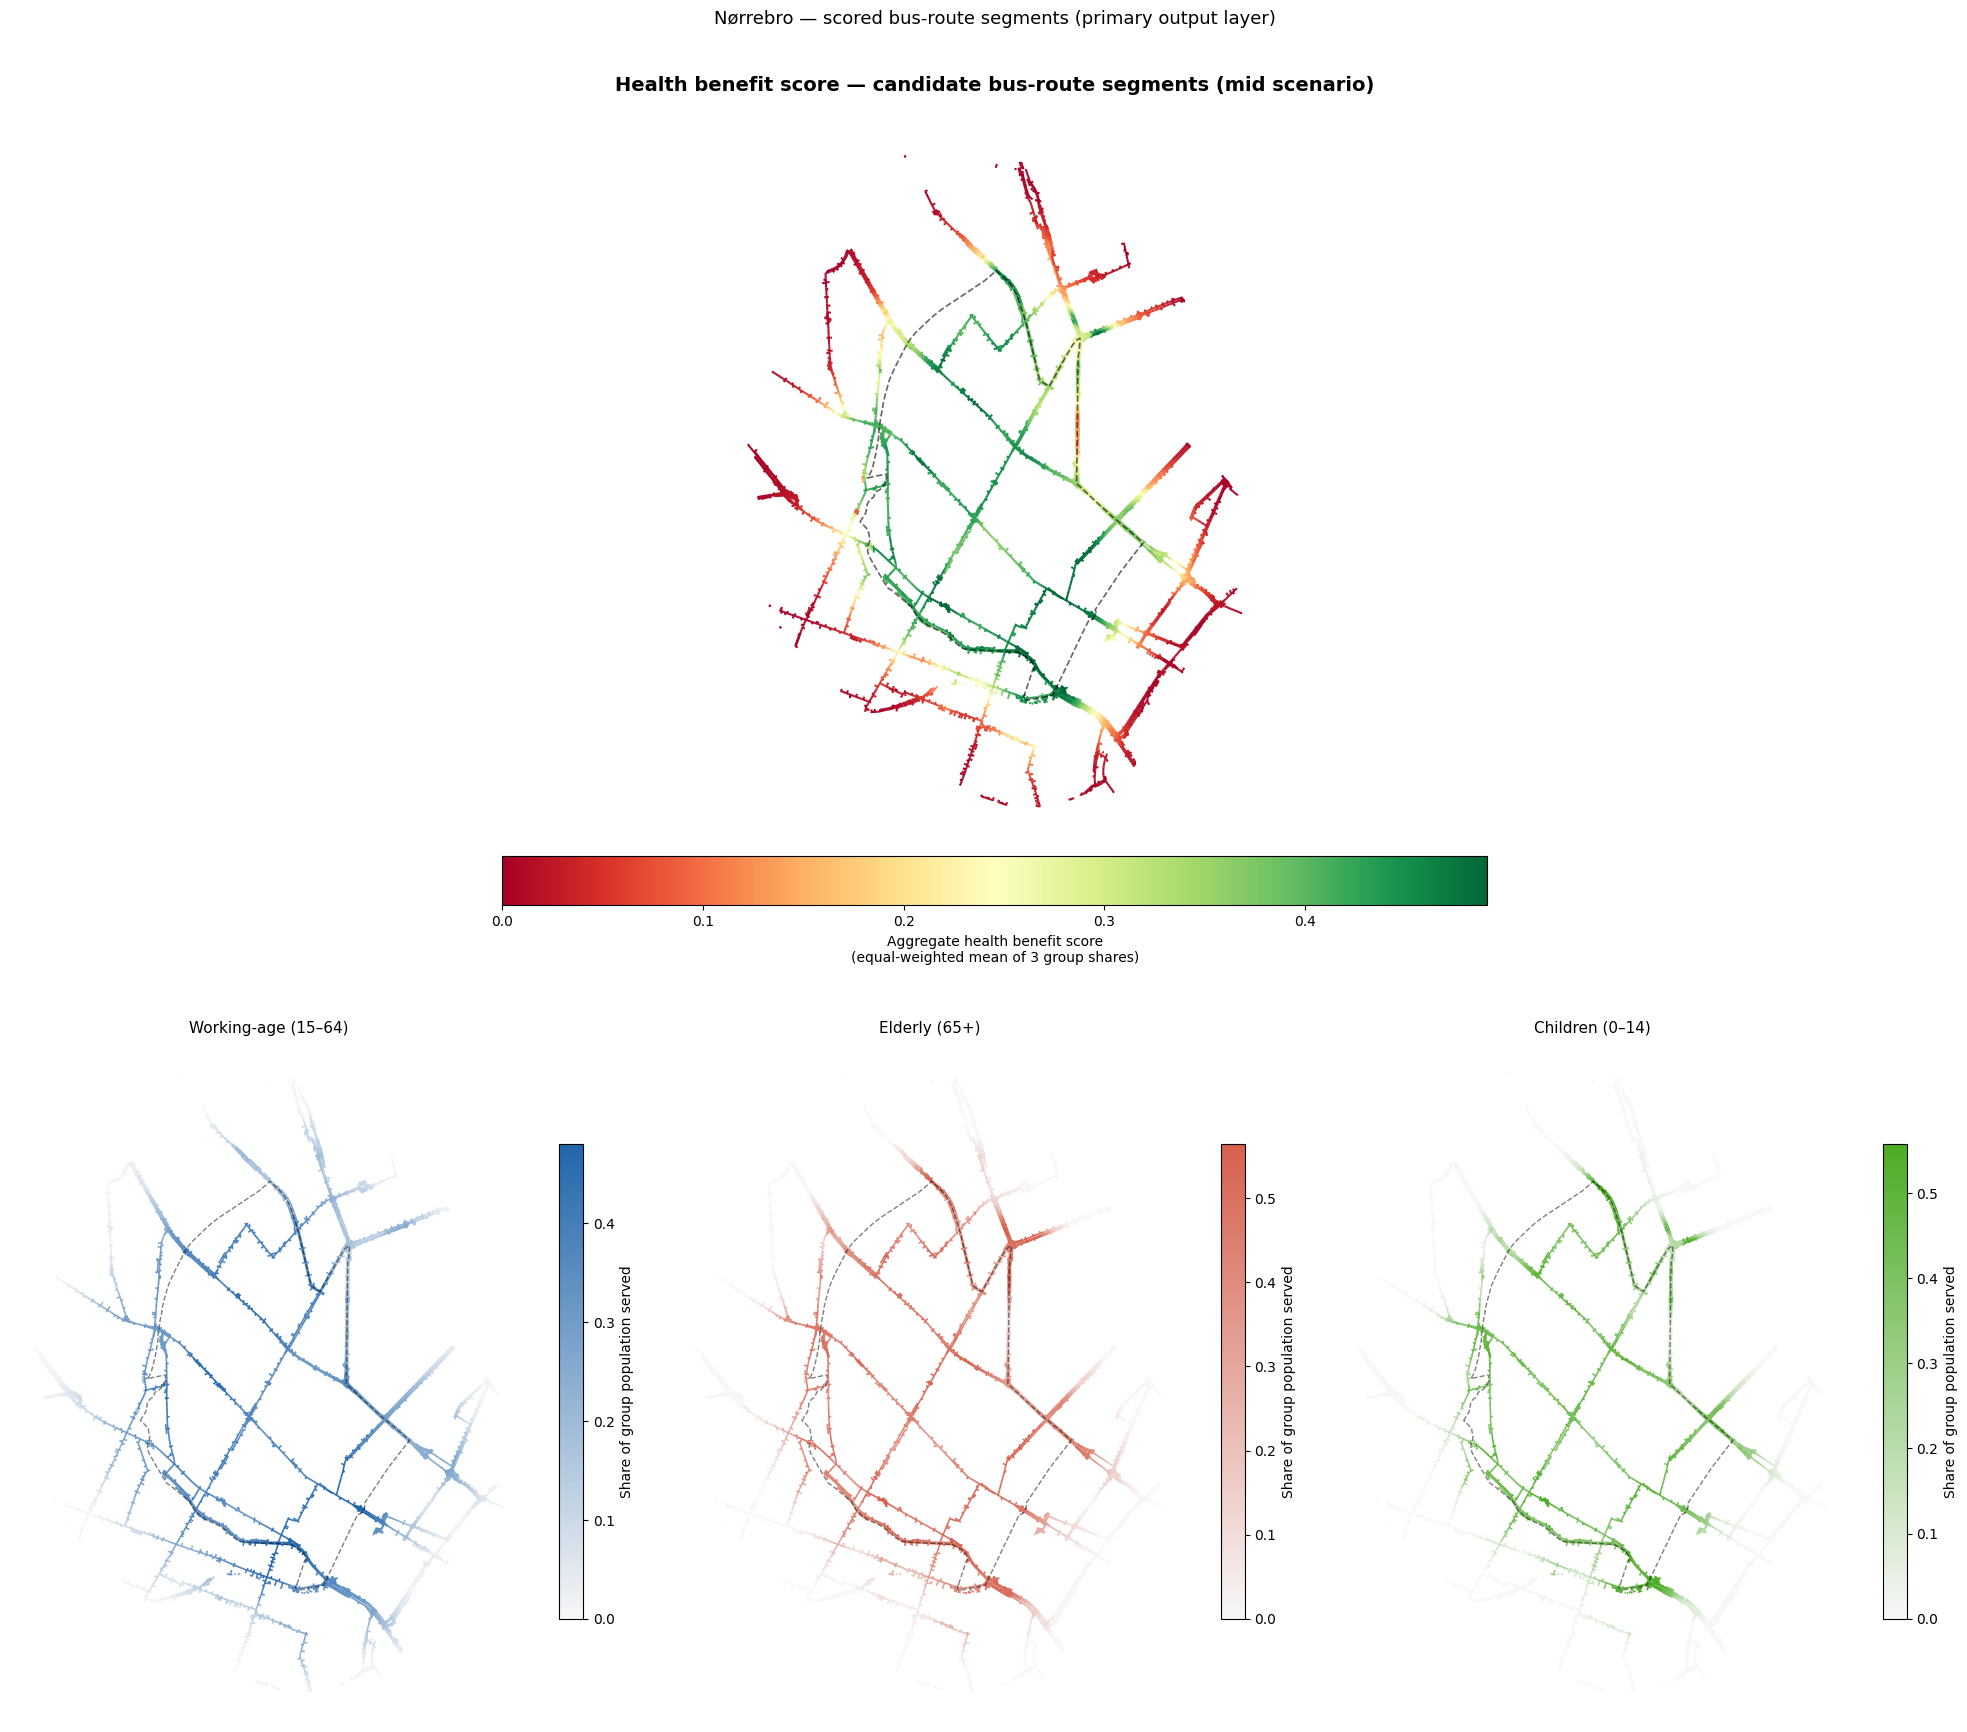

Live segments: 8,328

Aggregate score — top 10 segments:
                                                        score_aggregate_mid  score_working_age_mid_share  score_elderly_mid_share  score_children_mid_share
x723483.5-y6176662.4_x7234|662.4±0±x7235|700.7_k0                   0.53235                      0.47484                  0.54230                   0.57991
x723483.5-y6176662.4_x7234|662.4±0±x7235|623.7_k0                   0.53014                      0.47253                  0.53839                   0.57952
x7234|662.4±0±x7235|623.7_x7234|662.4±1±x7235|623.7_k0              0.52891                      0.47163                  0.53746                   0.57765
x723461.9-y6176665.1_x7234|665.1±0±x7234|681.2_k0                   0.52756                      0.48673                  0.54896                   0.54700
x723474.9-y6176672.2_x7234|709.2±1±x7234|672.2_k0                   0.52724                      0.48524                  0.54977                   0.54670
x723467

In [11]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from src.utils.config import NORREBRO_BOUNDARY_FILE, NORREBRO_BOUNDARY_LAYER

boundary = gpd.read_file(NORREBRO_BOUNDARY_FILE, layer=NORREBRO_BOUNDARY_LAYER)
live = nodes_gdf[nodes_gdf["live"] == True].copy()

# Check scores are populated — fall back gracefully if scoring hasn't run yet
AGG_COL = "score_aggregate_mid"
GROUP_COLS = {
    "Working-age (15–64)": ("score_working_age_mid_share", "#2166ac"),
    "Elderly (65+)": ("score_elderly_mid_share", "#d6604d"),
    "Children (0–14)": ("score_children_mid_share", "#4dac26"),
}

if AGG_COL not in live.columns or live[AGG_COL].max() == 0:
    print("Score columns not yet computed or all zero.")
    print(
        "Re-run compute_stats with full DISTANCES + all POP_COLS, then run the scoring cell."
    )
else:
    fig = plt.figure(figsize=(20, 18))

    # ── Top panel: aggregate score ────────────────────────────────────────────
    ax_main = fig.add_subplot(2, 1, 1)

    vmax_agg = live[AGG_COL].quantile(0.98)
    live.plot(
        column=AGG_COL,
        ax=ax_main,
        linewidth=1.5,
        cmap="RdYlGn",
        vmin=0,
        vmax=vmax_agg,
        legend=True,
        legend_kwds={
            "label": "Aggregate health benefit score\n(equal-weighted mean of 3 group shares)",
            "shrink": 0.5,
            "orientation": "horizontal",
            "pad": 0.02,
        },
    )
    boundary.boundary.plot(
        ax=ax_main, color="black", linewidth=1.2, linestyle="--", alpha=0.6
    )
    ax_main.set_title(
        "Health benefit score — candidate bus-route segments (mid scenario)",
        fontsize=14,
        fontweight="bold",
        pad=12,
    )
    ax_main.set_axis_off()

    # ── Bottom row: individual group share scores ─────────────────────────────
    for i, (label, (col, color)) in enumerate(GROUP_COLS.items()):
        ax = fig.add_subplot(2, 3, 4 + i)

        if col not in live.columns or live[col].max() == 0:
            ax.set_title(f"{label}\n(missing — re-run scoring cell)")
            ax.set_axis_off()
            continue

        # Build a single-hue colormap anchored to each group's colour
        cmap = mcolors.LinearSegmentedColormap.from_list(
            f"cmap_{label}", ["#f7f7f7", color]
        )
        vmax_grp = live[col].quantile(0.98)
        live.plot(
            column=col,
            ax=ax,
            linewidth=1.2,
            cmap=cmap,
            vmin=0,
            vmax=vmax_grp,
            legend=True,
            legend_kwds={"shrink": 0.55, "label": "Share of group population served"},
        )
        boundary.boundary.plot(
            ax=ax, color="black", linewidth=1, linestyle="--", alpha=0.5
        )
        ax.set_title(label, fontsize=11)
        ax.set_axis_off()

    plt.suptitle(
        "Nørrebro — scored bus-route segments (primary output layer)",
        fontsize=13,
        y=1.01,
    )
    plt.tight_layout()
    plt.show()

    # ── Numerical summary ─────────────────────────────────────────────────────
    print(f"Live segments: {len(live):,}")
    print(f"\nAggregate score — top 10 segments:")
    top = (
        live[
            [
                AGG_COL,
                "score_working_age_mid_share",
                "score_elderly_mid_share",
                "score_children_mid_share",
            ]
        ]
        .nlargest(10, AGG_COL)
        .round(5)
    )
    print(top.to_string())

In [12]:
import geopandas as gpd
from src.utils.config import NORREBRO_BOUNDARY_FILE, NORREBRO_BOUNDARY_LAYER

boundary = gpd.read_file(NORREBRO_BOUNDARY_FILE, layer=NORREBRO_BOUNDARY_LAYER)
EDGE_INSET_M = 80  # metres to erode inward from the district boundary

inner_poly = boundary.geometry.union_all().buffer(-EDGE_INSET_M)

# nodes_gdf geometry is the primal_edge midpoint (EPSG:25832)
nodes_gdf["interior"] = nodes_gdf.geometry.within(inner_poly)

n_live = (nodes_gdf["live"] == True).sum()
n_interior = nodes_gdf.loc[nodes_gdf["live"] == True, "interior"].sum()
print(f"Live segments:     {n_live:,}")
print(
    f"Interior (>{EDGE_INSET_M}m from boundary): {n_interior:,}  ({100 * n_interior / n_live:.1f}%)"
)
print(
    f"Edge-affected:     {n_live - n_interior:,}  ({100 * (n_live - n_interior) / n_live:.1f}%)"
)

Live segments:     8,328
Interior (>80m from boundary): 1,265  (15.2%)
Edge-affected:     7,063  (84.8%)


/Users/nfi/dev/healthy-transport/.venv/lib/python3.13/site-packages/geopandas/geodataframe.py:1969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)


In [13]:
from src.utils.config import (
    WEB_DATA_DIR,
    WEB_SEGMENTS_GEOJSON,
    WEB_BOUNDARY_GEOJSON,
    WEB_STOPS_GEOJSON,
    TRANSPORT_STOPS_OUTPUT,
    NORREBRO_BOUNDARY_FILE,
    NORREBRO_BOUNDARY_LAYER,
)

WEB_DATA_DIR.mkdir(parents=True, exist_ok=True)

# --- Scored bus-route segments ---
# CitySeer\'s nodes_gdf geometry column is not named "geometry" — use .geometry.name
# to get it, and rely on GeoDataFrame subsetting to carry it automatically.
geom_col = nodes_gdf.geometry.name
SCORE_COLS = [geom_col, "interior"] + [
    c for c in nodes_gdf.columns if c.startswith("score_")
]
live_segments = nodes_gdf[nodes_gdf["live"] == True][SCORE_COLS].copy()
live_segments.to_crs(epsg=4326).to_file(WEB_SEGMENTS_GEOJSON, driver="GeoJSON")
print(f"Segments exported:  {len(live_segments):,} \u2192 {WEB_SEGMENTS_GEOJSON.name}")

# --- District boundary ---
boundary_wgs = gpd.read_file(NORREBRO_BOUNDARY_FILE, layer=NORREBRO_BOUNDARY_LAYER)
boundary_wgs.to_crs(epsg=4326).to_file(WEB_BOUNDARY_GEOJSON, driver="GeoJSON")
print(f"Boundary exported:  {WEB_BOUNDARY_GEOJSON.name}")

# --- Existing bus stops (benchmark overlay) ---
stops_gdf = gpd.read_file(TRANSPORT_STOPS_OUTPUT, layer="stops")
bus_stops = stops_gdf[stops_gdf["transport_mode"] == "bus"].copy()
bus_stops.to_crs(epsg=4326).to_file(WEB_STOPS_GEOJSON, driver="GeoJSON")
print(f"Bus stops exported: {len(bus_stops):,} → {WEB_STOPS_GEOJSON.name}")

# File sizes
for f in [WEB_SEGMENTS_GEOJSON, WEB_BOUNDARY_GEOJSON, WEB_STOPS_GEOJSON]:
    if f.exists():
        print(f"  {f.name}: {f.stat().st_size / 1024:.0f} KB")

INFO:pyogrio._io:Created 8,328 records


INFO:pyogrio._io:Created 1 records


INFO:pyogrio._io:Created 2,581 records


Segments exported:  8,328 → norrebro_bus_segments_scored.geojson
Boundary exported:  norrebro_boundary.geojson
Bus stops exported: 2,581 → norrebro_stops.geojson
  norrebro_bus_segments_scored.geojson: 5118 KB
  norrebro_boundary.geojson: 16 KB
  norrebro_stops.geojson: 536 KB
